In [ ]:
# Install required packages
# Gerekli paketlerin kurulumu
!pip install -q albumentations timm openpyxl

# Mount Google Drive
# Google Drive baglama
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Paths
# Yollar
DATA_ROOT = "/content/drive/MyDrive/mini_dataset_2000"          # ham orijinal, a/b/c/d klasorleri
OUTPUT_ROOT = "/content/drive/MyDrive/breast_density/TwoViewDensityNet_alpha" # bu deneyin ciktilari
os.makedirs(OUTPUT_ROOT, exist_ok=True)

CLASSES = ["a", "b", "c", "d"]

# Paper-faithful hyperparameters
# Makaleye sadik hiperparametreler
IMG_H, IMG_W = 336, 224          # makale boyutu (yukseklik x genislik)
BATCH_SIZE = 16                  # T4 icin (makale 64, tek ayrildigimiz nokta)
MAX_EPOCHS = 50
PATIENCE = 7                     # makale early stopping
LR = 1e-4                        # makale baslangic LR
MOMENTUM = 0.9                   # makale SGD momentum
FOCAL_GAMMA = 0.5                # makale gamma araligi [0, 0.5]
N_FOLDS = 5                      # makale 5-fold CV
SEED = 42

# Morphology / threshold params from paper
# Makaleden morfoloji / esik parametreleri
THRESH_VALUE = 200               # 200 piksel esikleme
MORPH_KERNEL = 9                 # 9x9 disk yapisal eleman

assert os.path.exists(DATA_ROOT), f"DATA_ROOT bulunamadi: {DATA_ROOT}"
print("Veri dizini:", DATA_ROOT)
print("Alt klasorler:", os.listdir(DATA_ROOT))
print(f"\nMakale ayarlari: {IMG_H}x{IMG_W}, batch {BATCH_SIZE}, SGD lr {LR}, gamma {FOCAL_GAMMA}, {N_FOLDS}-fold")

Veri dizini: /content/drive/MyDrive/mini_dataset_2000
Alt klasorler: ['a', 'b', 'c', 'd']

Makale ayarlari: 336x224, batch 16, SGD lr 0.0001, gamma 0.5, 5-fold


In [ ]:
import pandas as pd

# Parse filename: {ID}_{SIDE}{VIEW}.png
# Dosya adini ayristir
def parse_filename(fname):
    base = os.path.splitext(fname)[0]
    parts = base.split("_")
    if len(parts) != 2:
        return None
    patient_id = parts[0]
    view_code = parts[1].upper()
    side = view_code[0]
    view = view_code[1:]
    if side not in ["L", "R"] or view not in ["CC", "MLO"]:
        return None
    return patient_id, side, view

# Scan all class folders
# Tum sinif klasorlerini tara
rows = []
for label in CLASSES:
    class_dir = os.path.join(DATA_ROOT, label)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if not fname.lower().endswith(".png"):
            continue
        parsed = parse_filename(fname)
        if parsed is None:
            continue
        patient_id, side, view = parsed
        rows.append({
            "patient_id": patient_id, "side": side, "view": view,
            "label": label, "filepath": os.path.join(class_dir, fname),
        })

df = pd.DataFrame(rows)

# Pivot to breast-level (one row per breast with CC and MLO paths)
# Meme bazli tabloya cevir (her satir bir meme, CC ve MLO yollari)
breast_df = df.pivot_table(
    index=["patient_id", "side", "label"],
    columns="view", values="filepath", aggfunc="first"
).reset_index()
breast_df.columns.name = None
breast_df = breast_df.rename(columns={"CC": "cc_path", "MLO": "mlo_path"})

label_to_idx = {c: i for i, c in enumerate(CLASSES)}
breast_df["label_idx"] = breast_df["label"].map(label_to_idx)

print("Toplam goruntu:", len(df))
print("Toplam meme (ornek):", len(breast_df))
print("\nMeme bazli sinif dagilimi:")
print(breast_df["label"].value_counts())

Toplam goruntu: 8000
Toplam meme (ornek): 4000

Meme bazli sinif dagilimi:
label
b    1414
c    1398
d     694
a     494
Name: count, dtype: int64


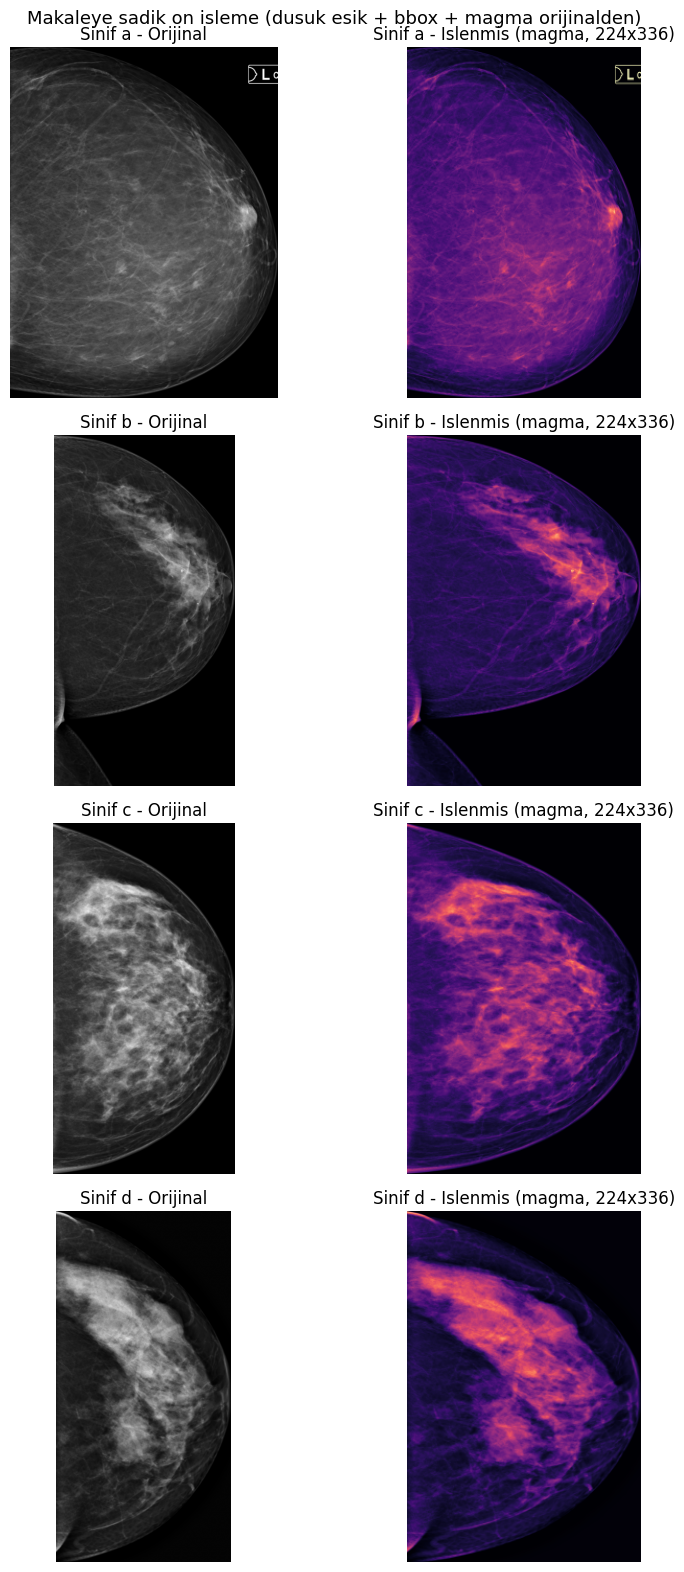

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Low fixed threshold: only separate true black background, keep all breast tissue
# Dusuk sabit esik: sadece gercek siyah arka plani ayir, tum meme dokusunu koru
BG_THRESH = 10

def preprocess_paper(img_gray):
    # Paper-faithful preprocessing, background-only threshold, magma from original
    # Makaleye sadik on isleme, sadece arka plan esigi, magma orijinalden
    # Mask is used ONLY for the crop box; magma is applied to the ORIGINAL grayscale
    # Maske SADECE kirpma kutusu icin; magma ORIJINAL griye uygulanir
    # This keeps class a intact and never punches holes in dense c/d tissue
    # Bu, a sinifini korur ve yogun c/d dokusunu asla delmez

    # Low threshold to isolate breast from black background
    # Memeyi siyah arka plandan ayirmak icin dusuk esik
    _, binary = cv2.threshold(img_gray, BG_THRESH, 255, cv2.THRESH_BINARY)

    # 9x9 disk opening to remove small artifacts (paper)
    # Kucuk artefaktlari kaldirmak icin 9x9 disk acilma (makale)
    disk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL, MORPH_KERNEL))
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, disk)

    # Largest connected component = breast
    # En buyuk bagli bilesen = meme
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(opened, connectivity=8)
    if num_labels <= 1:
        # No foreground found, use full image
        # On plan yok, tum goruntuyu kullan
        x1, y1 = 0, 0
        y2, x2 = img_gray.shape
        cropped = img_gray
    else:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        component = (labels == largest).astype(np.uint8)
        # Bounding box from the mask, but crop the ORIGINAL image (no holes)
        # Maskeden bbox, ama ORIJINAL goruntuyu kirp (delik yok)
        ys, xs = np.where(component > 0)
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()
        cropped = img_gray[y1:y2+1, x1:x2+1]

    # Magma colormap on the original cropped grayscale (intact tissue)
    # Orijinal kirpilmis gri uzerine magma (butun doku)
    magma = cv2.applyColorMap(cropped, cv2.COLORMAP_MAGMA)
    magma_rgb = cv2.cvtColor(magma, cv2.COLOR_BGR2RGB)

    # Resize to paper size
    # Makale boyutuna getir
    resized = cv2.resize(magma_rgb, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    return resized

# Visualize per class
# Sinif basina gorsellestir
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(9, 4 * len(CLASSES)))

for row_i, cls in enumerate(CLASSES):
    cls_row = breast_df[breast_df["label"] == cls].iloc[0]
    img = cv2.imread(cls_row["cc_path"], cv2.IMREAD_GRAYSCALE)
    processed = preprocess_paper(img)

    axes[row_i, 0].imshow(img, cmap="gray")
    axes[row_i, 0].set_title(f"Sinif {cls} - Orijinal")
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(processed)
    axes[row_i, 1].set_title(f"Sinif {cls} - Islenmis (magma, {IMG_W}x{IMG_H})")
    axes[row_i, 1].axis("off")

plt.suptitle("Makaleye sadik on isleme (dusuk esik + bbox + magma orijinalden)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
from tqdm import tqdm

# Local fast disk for processing
# Isleme icin hizli lokal disk
LOCAL_PROC = "/content/dataset_paper"
os.makedirs(LOCAL_PROC, exist_ok=True)

# Final destination on Drive
# Drive uzerindeki nihai hedef
PROC_ROOT = os.path.join(OUTPUT_ROOT, "dataset_processed")

def process_and_save_local(src_path, label):
    # Process (paper preprocessing) and save to local disk
    # Isle (makale on isleme) ve lokal diske kaydet
    fname = os.path.basename(src_path)
    dst_dir = os.path.join(LOCAL_PROC, label)
    os.makedirs(dst_dir, exist_ok=True)
    dst_path = os.path.join(dst_dir, fname)

    img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Okunamadi: {src_path}")
        return None

    processed = preprocess_paper(img)
    # processed is RGB; cv2.imwrite expects BGR, so convert back
    # processed RGB; cv2.imwrite BGR bekler, geri cevir
    cv2.imwrite(dst_path, cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))
    return dst_path

# Step 1: process everything to local disk
# Adim 1: her seyi lokal diske isle
print("Adim 1/2: Lokal diske isleniyor...")
cc_paths = []
mlo_paths = []
for _, row in tqdm(breast_df.iterrows(), total=len(breast_df)):
    cc_paths.append(process_and_save_local(row["cc_path"], row["label"]))
    mlo_paths.append(process_and_save_local(row["mlo_path"], row["label"]))

# Step 2: bulk copy to Drive
# Adim 2: Drive'a toplu kopyala
print("\nAdim 2/2: Drive'a toplu kopyalaniyor...")
if os.path.exists(PROC_ROOT):
    shutil.rmtree(PROC_ROOT)
shutil.copytree(LOCAL_PROC, PROC_ROOT)
print("Kopyalama tamamlandi.")

# Map local paths to Drive paths
# Lokal yollari Drive yollarina cevir
def local_to_drive(p):
    return p.replace(LOCAL_PROC, PROC_ROOT) if p else None

breast_df["cc_proc"] = [local_to_drive(p) for p in cc_paths]
breast_df["mlo_proc"] = [local_to_drive(p) for p in mlo_paths]

# Verify
# Dogrula
n_missing = breast_df["cc_proc"].isna().sum() + breast_df["mlo_proc"].isna().sum()
print(f"\nEksik kayit: {n_missing}")

# Save the table
# Tabloyu kaydet
table_path = os.path.join(OUTPUT_ROOT, "breast_table.csv")
breast_df.to_csv(table_path, index=False)
print(f"Tablo kaydedildi: {table_path}")
print(f"Islenmis goruntuler: {PROC_ROOT}")

Adim 1/2: Lokal diske isleniyor...


100%|██████████| 4000/4000 [2:52:18<00:00,  2.58s/it]



Adim 2/2: Drive'a toplu kopyalaniyor...
Kopyalama tamamlandi.

Eksik kayit: 0
Tablo kaydedildi: /content/drive/MyDrive/breast_density/TwoViewDensityNet_paper_faithful/breast_table.csv
Islenmis goruntuler: /content/drive/MyDrive/breast_density/TwoViewDensityNet_paper_faithful/dataset_processed


In [ ]:
import shutil
import pandas as pd

# Copy the table from the previous experiment (same folds, same processed paths)
# Onceki deneyden tabloyu kopyala (ayni foldlar, ayni islenmis yollar)
# Using identical folds makes the two experiments directly comparable
# Ayni foldlari kullanmak iki deneyi dogrudan karsilastirilabilir kilar
OLD_ROOT = "/content/drive/MyDrive/breast_density/TwoViewDensityNet_paper_faithful"
shutil.copy(os.path.join(OLD_ROOT, "breast_table.csv"),
            os.path.join(OUTPUT_ROOT, "breast_table.csv"))

breast_df = pd.read_csv(os.path.join(OUTPUT_ROOT, "breast_table.csv"))
print("Tablo kopyalandi (ayni fold split).")
print("Fold dagilimi:")
print(breast_df["fold"].value_counts().sort_index())

Tablo kopyalandi (ayni fold split).
Fold dagilimi:
fold
0    800
1    802
2    800
3    798
4    800
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

# Reload table if needed (in case of new session)
# Gerekirse tabloyu tekrar yukle (yeni oturum durumunda)
# breast_df already in memory; this is a safeguard
# breast_df zaten bellekte; bu bir onlem
table_path = os.path.join(OUTPUT_ROOT, "breast_table.csv")
if "cc_proc" not in breast_df.columns:
    breast_df = pd.read_csv(table_path)

# 5-fold stratified group split
# Group = patient_id (no leakage), stratify = breast label
# Grup = hasta ID (sizinti yok), stratify = meme etiketi
X = np.arange(len(breast_df))
y = breast_df["label_idx"].values
groups = breast_df["patient_id"].values

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Assign fold number to each sample
# Her ornege fold numarasi ata
breast_df["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(sgkf.split(X, y, groups)):
    breast_df.loc[val_idx, "fold"] = fold_idx

print("Fold dagilimi:")
print(breast_df["fold"].value_counts().sort_index())

# Verify class distribution per fold
# Fold basina sinif dagilimini dogrula
print("\nFold basina sinif dagilimi (%):")
fold_dist = breast_df.groupby("fold")["label"].value_counts(normalize=True).unstack() * 100
print(fold_dist.round(1))

# Verify no patient leakage across folds
# Foldlar arasi hasta sizintisi olmadigini dogrula
print("\nHasta sizintisi kontrolu:")
leak_found = False
for f in range(N_FOLDS):
    fold_patients = set(breast_df[breast_df["fold"] == f]["patient_id"])
    other_patients = set(breast_df[breast_df["fold"] != f]["patient_id"])
    overlap = fold_patients & other_patients
    if overlap:
        leak_found = True
        print(f"Fold {f}: {len(overlap)} hasta sizintisi!")
if not leak_found:
    print("Sizinti yok, dogrulandi.")

# Save table with folds
# Foldlarla tabloyu kaydet
breast_df.to_csv(table_path, index=False)
print(f"\nFold bilgisi tabloya eklendi: {table_path}")

Fold dagilimi:
fold
0    800
1    802
2    800
3    798
4    800
Name: count, dtype: int64

Fold basina sinif dagilimi (%):
label     a     b     c     d
fold                         
0      14.0  35.0  33.0  18.0
1      14.0  36.2  32.4  17.5
2      10.0  37.2  35.2  17.5
3      11.3  36.1  35.8  16.8
4      12.5  32.2  38.2  17.0

Hasta sizintisi kontrolu:
Sizinti yok, dogrulandi.

Fold bilgisi tabloya eklendi: /content/drive/MyDrive/breast_density/TwoViewDensityNet_alpha/breast_table.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Paper augmentation: 180 deg rotation, horizontal + vertical flip
# Makale augmentation: 180 derece rotasyon, yatay + dikey flip
# Note: images are already magma RGB and 336x224, so no resize needed here
# Not: goruntuler zaten magma RGB ve 336x224, burada resize gerekmez
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Rotate(limit=180, border_mode=cv2.BORDER_CONSTANT, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

class BreastDensityDataset(Dataset):
    # Two-view dataset reading processed magma RGB images
    # Islenmis magma RGB goruntuleri okuyan iki gorunumlu veri seti

    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        # Processed images are RGB (saved as BGR by cv2, read back and convert)
        # Islenmis goruntuler RGB (cv2 BGR kaydetti, oku ve cevir)
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Okunamadi: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cc = self._load(row["cc_proc"])
        mlo = self._load(row["mlo_proc"])
        cc = self.transform(image=cc)["image"]
        mlo = self.transform(image=mlo)["image"]
        return cc, mlo, int(row["label_idx"])

print("Dataset ve augmentation hazir (180 rotasyon + yatay/dikey flip, makaleye sadik).")

Dataset ve augmentation hazir (180 rotasyon + yatay/dikey flip, makaleye sadik).


In [ ]:
import torch.nn as nn
import torchvision.models as models

class TwoViewDensityNet(nn.Module):
    # Paper architecture: two ResNet-50 branches, concat, FC, softmax
    # Makale mimarisi: iki ResNet-50 dali, birlestir, FC, softmax

    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        cc_backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        )
        self.cc_features = nn.Sequential(*list(cc_backbone.children())[:-1])

        mlo_backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        )
        self.mlo_features = nn.Sequential(*list(mlo_backbone.children())[:-1])

        # Concatenated 2048 + 2048 = 4096, then FC to classes
        # Birlestirilmis 4096, sonra siniflara FC
        self.classifier = nn.Linear(2048 * 2, num_classes)

    def forward(self, cc, mlo):
        cc_feat = torch.flatten(self.cc_features(cc), 1)
        mlo_feat = torch.flatten(self.mlo_features(mlo), 1)
        combined = torch.cat([cc_feat, mlo_feat], dim=1)
        return self.classifier(combined)

# Quick test
# Hizli test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Cihaz:", device)

_m = TwoViewDensityNet().to(device)
_cc = torch.randn(2, 3, IMG_H, IMG_W).to(device)
_mlo = torch.randn(2, 3, IMG_H, IMG_W).to(device)
with torch.no_grad():
    _out = _m(_cc, _mlo)
print("Cikti sekli:", _out.shape)  # beklenen [2, 4]
print("Parametre:", sum(p.numel() for p in _m.parameters()) / 1e6, "M")
del _m, _cc, _mlo
torch.cuda.empty_cache()

Cihaz: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s]


Cikti sekli: torch.Size([2, 4])
Parametre: 47.032452 M


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class FocalLoss(nn.Module):
    # Focal loss with optional class weights (alpha)
    # Istege bagli sinif agirliklari (alpha) ile focal loss

    def __init__(self, gamma=0.5, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def compute_alpha(train_df_fold, device, num_classes=4):
    # Square-root softened inverse frequency weights
    # Karekok yumusatilmis ters frekans agirliklari
    # Ratio between highest and lowest weight is about 1.68x
    # En yuksek ve en dusuk agirlik orani yaklasik 1.68x
    counts = train_df_fold["label_idx"].value_counts().sort_index().values
    inv_freq = 1.0 / counts
    soft = np.sqrt(inv_freq)
    soft = soft / soft.sum() * num_classes
    return torch.tensor(soft, dtype=torch.float32).to(device)

print(f"Alpha'li focal loss hazir (gamma={FOCAL_GAMMA}, karekok yumusatma).")

Alpha'li focal loss hazir (gamma=0.5, karekok yumusatma).


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes=4):
    # Evaluate model, return metrics and raw outputs
    # Modeli degerlendir, metrikleri ve ham ciktilari dondur
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for cc, mlo, labels in loader:
        cc, mlo, labels = cc.to(device), mlo.to(device), labels.to(device)
        outputs = model(cc, mlo)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * labels.size(0)

        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro"),
    }
    try:
        metrics["macro_auc"] = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError:
        metrics["macro_auc"] = float("nan")

    per_class = f1_score(all_labels, all_preds, average=None, labels=list(range(num_classes)))
    for i in range(num_classes):
        metrics[f"f1_{CLASSES[i]}"] = per_class[i]

    return metrics, all_labels, all_preds, all_probs

print("Metrik fonksiyonu hazir.")

Metrik fonksiyonu hazir.


In [ ]:
import torch.optim as optim
from tqdm import tqdm
import pandas as pd
import os
import shutil

# Local fast directory for checkpoints/logs (no Drive freeze)
# Checkpoint/log icin hizli lokal dizin (Drive donmasi yok)
LOCAL_OUT = "/content/local_out"
os.makedirs(LOCAL_OUT, exist_ok=True)

# How often to sync local -> Drive
# Lokal -> Drive senkronizasyon sikligi
SYNC_EVERY = 5

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for cc, mlo, labels in tqdm(loader, desc="Train", leave=False):
        cc, mlo, labels = cc.to(device), mlo.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(cc, mlo)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
    return total_loss / len(loader.dataset)

def save_ckpt(path, fold, epoch, model, optimizer, best_val_loss, no_improve):
    torch.save({
        "fold": fold, "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_loss": best_val_loss, "no_improve": no_improve,
    }, path)

def sync_to_drive(local_dir, drive_dir):
    # Copy only the needed files, overwrite in place, no deletion
    # Sadece gerekli dosyalari kopyala, uzerine yaz, silme yok
    # Avoids rmtree + copytree which caused Drive freezes
    # Drive donmasina yol acan rmtree + copytree kullanilmaz
    os.makedirs(drive_dir, exist_ok=True)
    for fname in ["last.pt", "best.pt", "log.xlsx"]:
        src = os.path.join(local_dir, fname)
        if not os.path.exists(src):
            continue
        dst = os.path.join(drive_dir, fname)
        try:
            shutil.copy2(src, dst)
        except Exception as e:
            # Drive can be flaky; log and continue, local copy is safe
            # Drive kararsiz olabilir; logla ve devam et, lokal kopya guvende
            print(f"  Uyari: {fname} Drive'a yazilamadi ({e}), lokal kopya duruyor")

# Load fold progress (from Drive, for resume across sessions)
# Fold ilerlemesini yukle (Drive'dan, oturumlar arasi resume)
progress_path = os.path.join(OUTPUT_ROOT, "fold_progress.csv")
if os.path.exists(progress_path):
    fold_results = pd.read_csv(progress_path).to_dict("records")
    done_folds = [r["fold"] for r in fold_results]
    print(f"Tamamlanan foldlar: {done_folds}")
else:
    fold_results, done_folds = [], []

# ===== 5-FOLD LOOP =====
for fold in range(N_FOLDS):
    if fold in done_folds:
        print(f"Fold {fold} zaten tamamlanmis, atlaniyor.")
        continue

    print(f"\n{'='*50}\nFOLD {fold}\n{'='*50}")

    test_mask = breast_df["fold"] == fold
    val_fold = (fold + 1) % N_FOLDS
    val_mask = breast_df["fold"] == val_fold
    train_mask = ~test_mask & ~val_mask

    train_df_f = breast_df[train_mask].copy()
    val_df_f = breast_df[val_mask].copy()
    test_df_f = breast_df[test_mask].copy()
    print(f"Train: {len(train_df_f)}, Val: {len(val_df_f)}, Test: {len(test_df_f)}")

    train_loader = DataLoader(BreastDensityDataset(train_df_f, train_transform),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                              pin_memory=True, drop_last=True)
    val_loader = DataLoader(BreastDensityDataset(val_df_f, eval_transform),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(BreastDensityDataset(test_df_f, eval_transform),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = TwoViewDensityNet(num_classes=4, pretrained=True).to(device)
    # Compute alpha from this fold's training distribution
    # Bu fold'un egitim dagilimindan alpha hesapla
    alpha = compute_alpha(train_df_f, device)
    criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=alpha)
    print(f"Alpha (a,b,c,d): {alpha.cpu().numpy().round(3)}")
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

    # Local and Drive paths for this fold
    # Bu fold icin lokal ve Drive yollari
    local_fold = os.path.join(LOCAL_OUT, f"fold_{fold}")
    drive_fold = os.path.join(OUTPUT_ROOT, f"fold_{fold}")
    os.makedirs(local_fold, exist_ok=True)

    last_ckpt = os.path.join(local_fold, "last.pt")
    best_ckpt = os.path.join(local_fold, "best.pt")
    excel_log = os.path.join(local_fold, "log.xlsx")

    # Resume: prefer local, else pull from Drive
    # Resume: once lokal, yoksa Drive'dan cek
    start_epoch, best_val_loss, no_improve = 0, float("inf"), 0
    log_rows = []
    resume_src = None
    if os.path.exists(last_ckpt):
        resume_src = last_ckpt
    elif os.path.exists(os.path.join(drive_fold, "last.pt")):
        # Copy Drive fold back to local to resume
        # Devam icin Drive fold'unu lokale kopyala
        sync_to_drive(drive_fold, local_fold)  # drive -> local (same function, dirs swapped)
        resume_src = last_ckpt

    if resume_src and os.path.exists(resume_src):
        ck = torch.load(resume_src, map_location=device)
        model.load_state_dict(ck["model_state"])
        optimizer.load_state_dict(ck["optimizer_state"])
        start_epoch = ck["epoch"] + 1
        best_val_loss = ck["best_val_loss"]
        no_improve = ck["no_improve"]
        if os.path.exists(excel_log):
            log_rows = pd.read_excel(excel_log).to_dict("records")
        print(f"Fold {fold} epoch {start_epoch}'dan devam ediyor.")

    for epoch in range(start_epoch, MAX_EPOCHS):
        train_one_epoch(model, train_loader, criterion, optimizer, device)
        tr_m, _, _, _ = evaluate(model, train_loader, criterion, device)
        va_m, _, _, _ = evaluate(model, val_loader, criterion, device)

        print(f"F{fold} E{epoch:02d} | tr_loss {tr_m['loss']:.3f} acc {tr_m['accuracy']:.3f} | "
              f"va_loss {va_m['loss']:.3f} acc {va_m['accuracy']:.3f} f1 {va_m['macro_f1']:.3f}")

        row = {"epoch": epoch}
        for k, v in tr_m.items(): row[f"train_{k}"] = v
        for k, v in va_m.items(): row[f"val_{k}"] = v
        log_rows.append(row)

        # Write to LOCAL every epoch (fast, no freeze)
        # Her epoch LOKALE yaz (hizli, donma yok)
        pd.DataFrame(log_rows).to_excel(excel_log, index=False)

        if va_m["loss"] < best_val_loss:
            best_val_loss = va_m["loss"]
            no_improve = 0
            save_ckpt(best_ckpt, fold, epoch, model, optimizer, best_val_loss, no_improve)
        else:
            no_improve += 1
        save_ckpt(last_ckpt, fold, epoch, model, optimizer, best_val_loss, no_improve)

        # Sync to Drive every SYNC_EVERY epochs
        # Her SYNC_EVERY epoch'ta Drive'a senkronize et
        if (epoch + 1) % SYNC_EVERY == 0:
            sync_to_drive(local_fold, drive_fold)
            print(f"  (Drive'a senkronize edildi, epoch {epoch})")

        if no_improve >= PATIENCE:
            print(f"  Early stopping (fold {fold}, epoch {epoch})")
            break

    # Final sync for this fold
    # Bu fold icin son senkronizasyon
    sync_to_drive(local_fold, drive_fold)

    # Evaluate best model on test set
    # En iyi modeli test setinde degerlendir
    ck = torch.load(best_ckpt, map_location=device)
    model.load_state_dict(ck["model_state"])
    test_m, _, _, _ = evaluate(model, test_loader, criterion, device)
    print(f"Fold {fold} TEST: acc {test_m['accuracy']:.3f}, f1 {test_m['macro_f1']:.3f}, auc {test_m['macro_auc']:.3f}")

    result = {"fold": fold, "test_accuracy": test_m["accuracy"],
              "test_macro_f1": test_m["macro_f1"], "test_macro_auc": test_m["macro_auc"]}
    for c in CLASSES:
        result[f"test_f1_{c}"] = test_m[f"f1_{c}"]
    fold_results.append(result)
    # Progress CSV to Drive (small file, safe)
    # Ilerleme CSV'si Drive'a (kucuk dosya, guvenli)
    pd.DataFrame(fold_results).to_csv(progress_path, index=False)

    del model, optimizer
    torch.cuda.empty_cache()

# ===== FINAL =====
res_df = pd.DataFrame(fold_results)
print(f"\n{'='*50}\n5-FOLD SONUCLARI\n{'='*50}")
print(res_df.round(4).to_string(index=False))
print("\nOrtalama +/- std:")
for col in ["test_accuracy", "test_macro_f1", "test_macro_auc"]:
    print(f"  {col}: {res_df[col].mean():.4f} +/- {res_df[col].std():.4f}")

Tamamlanan foldlar: [0, 1, 2, 3]
Fold 0 zaten tamamlanmis, atlaniyor.
Fold 1 zaten tamamlanmis, atlaniyor.
Fold 2 zaten tamamlanmis, atlaniyor.
Fold 3 zaten tamamlanmis, atlaniyor.

FOLD 4
Train: 2400, Val: 800, Test: 800
Alpha (a,b,c,d): [1.344 0.763 0.784 1.109]
Fold 4 epoch 13'dan devam ediyor.


F4 E13 | tr_loss 0.424 acc 0.732 | va_loss 0.427 acc 0.738 f1 0.739


F4 E14 | tr_loss 0.421 acc 0.728 | va_loss 0.433 acc 0.738 f1 0.739
  (Drive'a senkronize edildi, epoch 14)


F4 E15 | tr_loss 0.411 acc 0.738 | va_loss 0.421 acc 0.757 f1 0.758


F4 E16 | tr_loss 0.413 acc 0.736 | va_loss 0.414 acc 0.759 f1 0.758


...

F4 E45 | tr_loss 0.325 acc 0.782 | va_loss 0.377 acc 0.769 f1 0.770


F4 E46 | tr_loss 0.328 acc 0.774 | va_loss 0.373 acc 0.774 f1 0.773


F4 E47 | tr_loss 0.323 acc 0.787 | va_loss 0.387 acc 0.756 f1 0.759


F4 E48 | tr_loss 0.320 acc 0.783 | va_loss 0.369 acc 0.771 f1 0.774


F4 E49 | tr_loss 0.319 acc 0.790 | va_loss 0.381 acc 0.759 f1 0.761
  (Drive'a senkronize edildi, epoch 49)
Fold 4 TEST: acc 0.711, f1 0.711, auc 0.920

5-FOLD SONUCLARI
 fold  test_accuracy  test_macro_f1  test_macro_auc  test_f1_a  test_f1_b  test_f1_c  test_f1_d
    0         0.7550         0.7577          0.9327     0.7068     0.7407     0.7510     0.8322
    1         0.7531         0.7491          0.9321     0.7168     0.7805     0.7236     0.7756
    2         0.7250         0.7101          0.9137     0.6182     0.7466     0.7124     0.7632
    3         0.7080         0.7024          0.9180     0.6063     0.6872     0.7300     0.7860
    4         0.7113         0.7109          0.9198     0.7018     0.6944     0.7233     0.7240

Ortalama +/- std:
  test_accuracy: 0.7305 +/- 0.0225
  test_macro_f1: 0.7260 +/- 0.0254
  test_macro_auc: 0.9233 +/- 0.0087


In [ ]:
import numpy as np
import torch

# Collect out-of-fold test predictions from all 5 folds
# 5 fold'un tumunden test tahminlerini topla
# Each sample is tested exactly once (in its own fold)
# Her ornek tam bir kez test edilir (kendi fold'unda)

all_labels_oof = []
all_preds_oof = []
all_probs_oof = []

for fold in range(N_FOLDS):
    print(f"Fold {fold} test tahminleri hesaplaniyor...")

    # Test set for this fold
    # Bu fold'un test seti
    test_df_f = breast_df[breast_df["fold"] == fold].copy()
    test_loader = DataLoader(BreastDensityDataset(test_df_f, eval_transform),
                             batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)

    # Load this fold's best model
    # Bu fold'un en iyi modelini yukle
    best_path = os.path.join(OUTPUT_ROOT, f"fold_{fold}", "best.pt")
    model = TwoViewDensityNet(num_classes=4, pretrained=False).to(device)
    ck = torch.load(best_path, map_location=device)
    model.load_state_dict(ck["model_state"])

    criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=None)
    _, labels, preds, probs = evaluate(model, test_loader, criterion, device)

    all_labels_oof.append(labels)
    all_preds_oof.append(preds)
    all_probs_oof.append(probs)

    del model
    torch.cuda.empty_cache()

# Concatenate all folds
# Tum foldlari birlestir
labels_oof = np.concatenate(all_labels_oof)
preds_oof = np.concatenate(all_preds_oof)
probs_oof = np.concatenate(all_probs_oof)

print(f"\nToplam test edilen ornek: {len(labels_oof)}")
print(f"Beklenen: {len(breast_df)}")

Fold 0 test tahminleri hesaplaniyor...
Fold 1 test tahminleri hesaplaniyor...
Fold 2 test tahminleri hesaplaniyor...
Fold 3 test tahminleri hesaplaniyor...
Fold 4 test tahminleri hesaplaniyor...

Toplam test edilen ornek: 4000
Beklenen: 4000


=== BIRLESTIRILMIS 5-FOLD SONUCLARI (tum 4000 ornek) ===
Accuracy: 0.7385
Macro F1: 0.7255
Cohen Kappa: 0.6273
Weighted Kappa: 0.8318

=== Siniflandirma Raporu ===
              precision    recall  f1-score   support

           a      0.708     0.573     0.633       494
           b      0.713     0.791     0.750      1414
           c      0.754     0.727     0.740      1398
           d      0.785     0.772     0.779       694

    accuracy                          0.739      4000
   macro avg      0.740     0.716     0.725      4000
weighted avg      0.739     0.739     0.737      4000



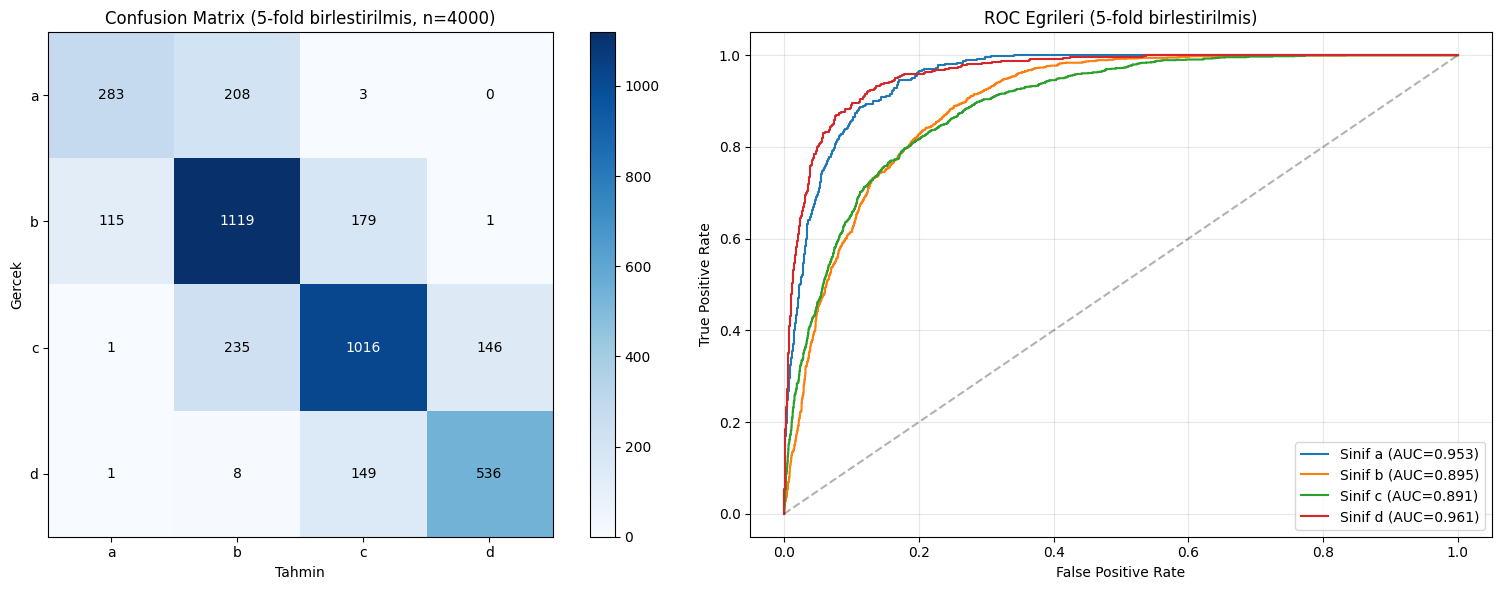


Grafik kaydedildi: /content/drive/MyDrive/breast_density/TwoViewDensityNet_paper_faithful/oof_confusion_roc.png

=== Kritik hata kontrolu ===
Gercek a, tahmin d: 0 ornek
Gercek d, tahmin a: 1 ornek
(a ve d gorsel olarak zit kutuplar, bu karisma minimum olmali)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score, f1_score, cohen_kappa_score)
from sklearn.preprocessing import label_binarize

# Overall metrics on combined out-of-fold predictions
# Birlestirilmis fold-disi tahminler uzerinde genel metrikler
print("=== BIRLESTIRILMIS 5-FOLD SONUCLARI (tum 4000 ornek) ===")
print(f"Accuracy: {accuracy_score(labels_oof, preds_oof):.4f}")
print(f"Macro F1: {f1_score(labels_oof, preds_oof, average='macro'):.4f}")
print(f"Cohen Kappa: {cohen_kappa_score(labels_oof, preds_oof):.4f}")
print(f"Weighted Kappa: {cohen_kappa_score(labels_oof, preds_oof, weights='quadratic'):.4f}")

print("\n=== Siniflandirma Raporu ===")
print(classification_report(labels_oof, preds_oof, target_names=CLASSES, digits=3))

# Plot confusion matrix and ROC
# Confusion matrix ve ROC ciz
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
# Karisiklik matrisi
cm = confusion_matrix(labels_oof, preds_oof)
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix (5-fold birlestirilmis, n=4000)")
axes[0].set_xlabel("Tahmin")
axes[0].set_ylabel("Gercek")
axes[0].set_xticks(range(len(CLASSES)))
axes[0].set_yticks(range(len(CLASSES)))
axes[0].set_xticklabels(CLASSES)
axes[0].set_yticklabels(CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=axes[0])

# ROC curves per class
# Sinif basina ROC egrileri
labels_bin = label_binarize(labels_oof, classes=list(range(len(CLASSES))))
for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs_oof[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f"Sinif {c} (AUC={roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("ROC Egrileri (5-fold birlestirilmis)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_ROOT, "oof_confusion_roc.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nGrafik kaydedildi: {fig_path}")

# Highlight the critical a<->d confusion (Mehmet Bey's concern)
# Kritik a<->d karismasini vurgula (Mehmet Bey'in dikkat cektigi)
a_idx, d_idx = CLASSES.index("a"), CLASSES.index("d")
print(f"\n=== Kritik hata kontrolu ===")
print(f"Gercek a, tahmin d: {cm[a_idx, d_idx]} ornek")
print(f"Gercek d, tahmin a: {cm[d_idx, a_idx]} ornek")
print("(a ve d gorsel olarak zit kutuplar, bu karisma minimum olmali)")

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    # Grad-CAM for the two-branch model
    # Iki dalli model icin Grad-CAM
    # Hooks into the last conv layer of a given branch
    # Verilen dalin son konvolusyon katmanina baglanir

    def __init__(self, model, target_branch):
        # target_branch: "cc" or "mlo"
        # target_branch: "cc" veya "mlo"
        self.model = model
        self.model.eval()
        self.branch = target_branch

        # Last conv block of ResNet-50 is layer4, which is index 7 in children()
        # ResNet-50'nin son conv blogu layer4, children() icinde 7. indeks
        features = model.cc_features if target_branch == "cc" else model.mlo_features
        self.target_layer = features[7]  # layer4

        self.activations = None
        self.gradients = None

        # Register hooks
        # Hook'lari kaydet
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, cc, mlo, target_class=None):
        # Forward pass
        # Ileri gecis
        output = self.model(cc, mlo)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Backward on the target class score
        # Hedef sinif skoru uzerinden geri yayilim
        self.model.zero_grad()
        output[0, target_class].backward()

        # Weight activations by mean gradient (channel importance)
        # Aktivasyonlari ortalama gradyan ile agirlikla (kanal onemi)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # B, C, 1, 1
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # B, 1, H, W
        cam = F.relu(cam)

        # Normalize to 0-1
        # 0-1 arasina normalize et
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, target_class, output.softmax(dim=1)[0].detach().cpu().numpy()

def overlay_cam(img_rgb, cam, alpha=0.5):
    # Overlay heatmap on image
    # Isi haritasini goruntu uzerine bindir
    cam_resized = cv2.resize(cam, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(alpha * heatmap + (1 - alpha) * img_rgb)
    return overlay

print("Grad-CAM hazir.")

Grad-CAM hazir.


=== DOGRU TAHMINLER (sinif basina bir ornek) ===



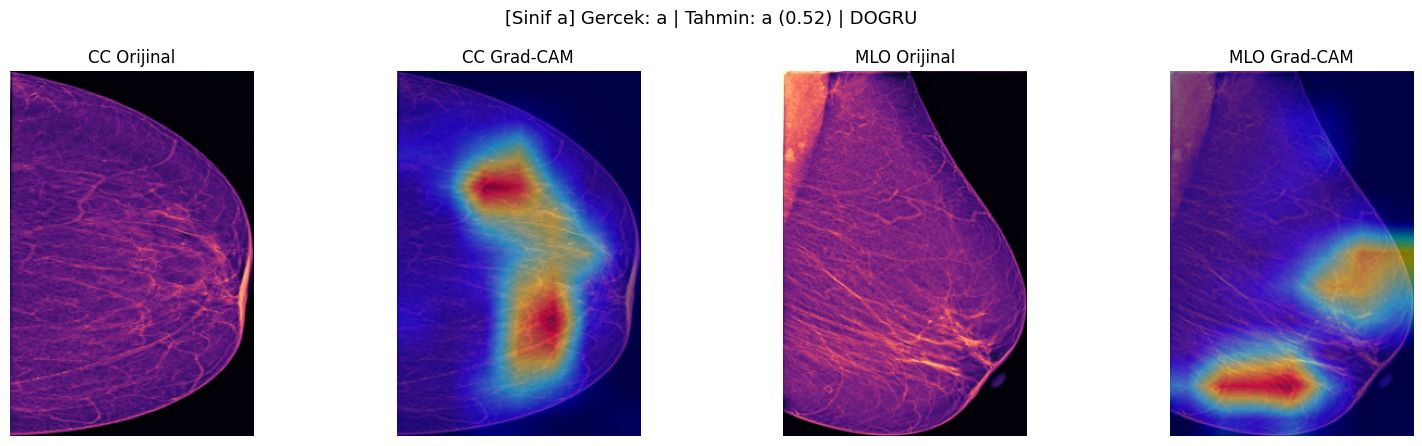

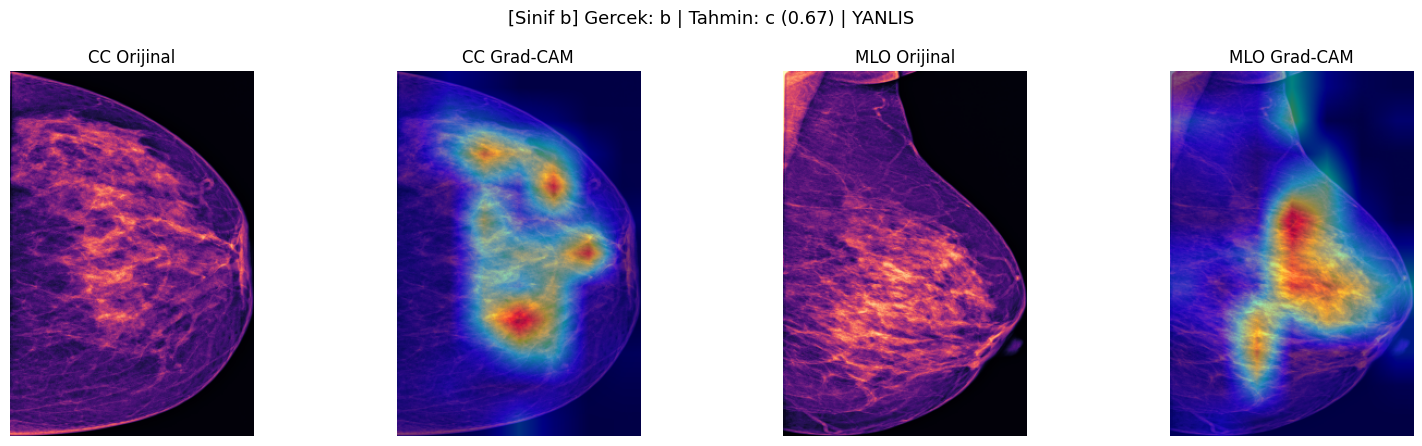

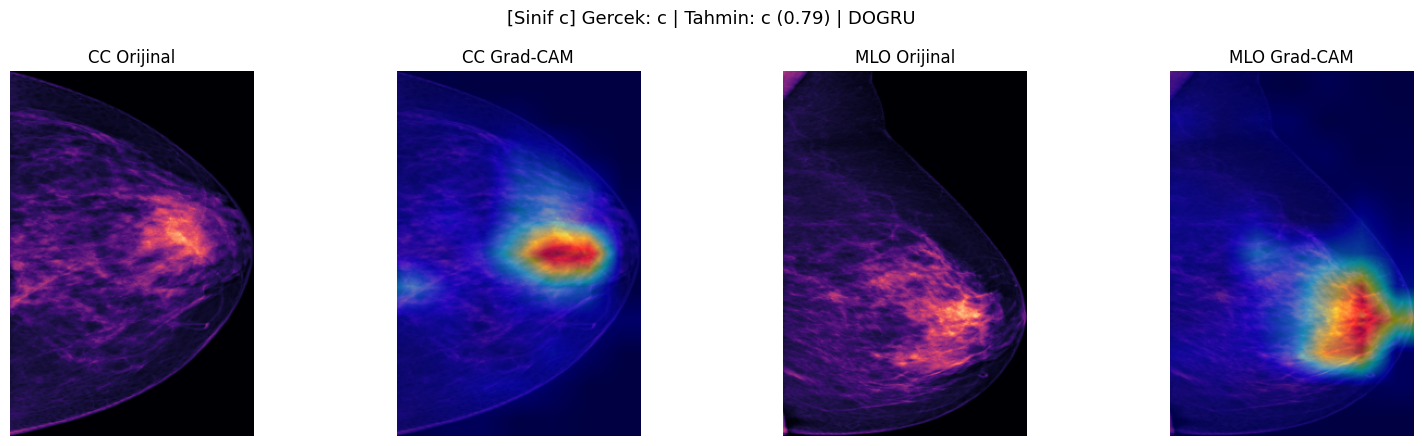

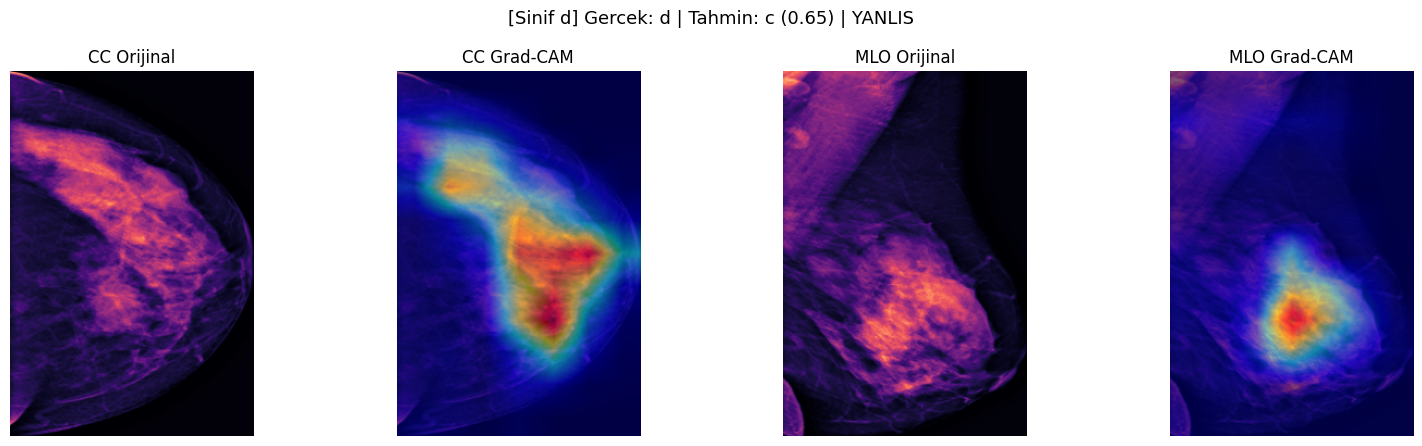

In [ ]:
# Load a trained model (fold 0's best)
# Egitilmis bir modeli yukle (fold 0'in en iyisi)
model_gc = TwoViewDensityNet(num_classes=4, pretrained=False).to(device)
ck = torch.load(os.path.join(OUTPUT_ROOT, "fold_0", "best.pt"), map_location=device)
model_gc.load_state_dict(ck["model_state"])
model_gc.eval()

gradcam_cc = GradCAM(model_gc, "cc")
gradcam_mlo = GradCAM(model_gc, "mlo")

def visualize_gradcam(row, title_prefix=""):
    # Load and preprocess a breast (both views)
    # Bir memeyi yukle ve isle (iki gorunum)
    cc_img = cv2.cvtColor(cv2.imread(row["cc_proc"], cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    mlo_img = cv2.cvtColor(cv2.imread(row["mlo_proc"], cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    cc_t = eval_transform(image=cc_img)["image"].unsqueeze(0).to(device)
    mlo_t = eval_transform(image=mlo_img)["image"].unsqueeze(0).to(device)

    # Generate CAMs for both branches
    # Iki dal icin CAM uret
    cam_cc, pred_cls, probs = gradcam_cc.generate(cc_t, mlo_t)
    cam_mlo, _, _ = gradcam_mlo.generate(cc_t, mlo_t)

    true_cls = row["label"]
    pred_label = CLASSES[pred_cls]
    conf = probs[pred_cls]

    # Plot: original CC, CAM CC, original MLO, CAM MLO
    # Ciz: orijinal CC, CAM CC, orijinal MLO, CAM MLO
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

    axes[0].imshow(cc_img)
    axes[0].set_title("CC Orijinal")
    axes[0].axis("off")

    axes[1].imshow(overlay_cam(cc_img, cam_cc))
    axes[1].set_title("CC Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(mlo_img)
    axes[2].set_title("MLO Orijinal")
    axes[2].axis("off")

    axes[3].imshow(overlay_cam(mlo_img, cam_mlo))
    axes[3].set_title("MLO Grad-CAM")
    axes[3].axis("off")

    status = "DOGRU" if pred_label == true_cls else "YANLIS"
    plt.suptitle(f"{title_prefix} Gercek: {true_cls} | Tahmin: {pred_label} ({conf:.2f}) | {status}",
                 fontsize=13)
    plt.tight_layout()
    plt.show()

# Test set of fold 0 (the model has not seen these)
# Fold 0'in test seti (model bunlari gormedi)
test_f0 = breast_df[breast_df["fold"] == 0].copy()

# Show one correct example per class
# Sinif basina bir dogru ornek goster
print("=== DOGRU TAHMINLER (sinif basina bir ornek) ===\n")
for cls in CLASSES:
    cls_rows = test_f0[test_f0["label"] == cls]
    if len(cls_rows) > 0:
        visualize_gradcam(cls_rows.iloc[0], title_prefix=f"[Sinif {cls}]")

In [ ]:
import os
import pandas as pd
import numpy as np
import torch

# Paths to both experiments
# Iki deneyin yollari
ROOT_NOALPHA = "/content/drive/MyDrive/breast_density/TwoViewDensityNet_paper_faithful"
ROOT_ALPHA = "/content/drive/MyDrive/breast_density/TwoViewDensityNet_alpha"

EXPERIMENTS = {
    "Alpha'siz (papere sadik)": ROOT_NOALPHA,
    "Alpha'li (karekok)": ROOT_ALPHA,
}

# Load fold results
# Fold sonuclarini yukle
results = {}
for name, root in EXPERIMENTS.items():
    prog = pd.read_csv(os.path.join(root, "fold_progress.csv"))
    results[name] = prog
    print(f"{name}: {len(prog)} fold yuklendi")

# Load per-fold training logs and average across folds
# Fold bazli egitim loglarini yukle ve foldlar arasi ortala
logs = {}
for name, root in EXPERIMENTS.items():
    fold_logs = []
    for fold in range(5):
        log_path = os.path.join(root, f"fold_{fold}", "log.xlsx")
        if os.path.exists(log_path):
            df = pd.read_excel(log_path)
            df["fold"] = fold
            fold_logs.append(df)
    logs[name] = pd.concat(fold_logs, ignore_index=True) if fold_logs else None
    if logs[name] is not None:
        print(f"{name}: egitim loglari yuklendi ({len(logs[name])} satir)")

print("\nVeriler hazir.")

Alpha'siz (papere sadik): 5 fold yuklendi
Alpha'li (karekok): 5 fold yuklendi
Alpha'siz (papere sadik): egitim loglari yuklendi (207 satir)
Alpha'li (karekok): egitim loglari yuklendi (239 satir)

Veriler hazir.


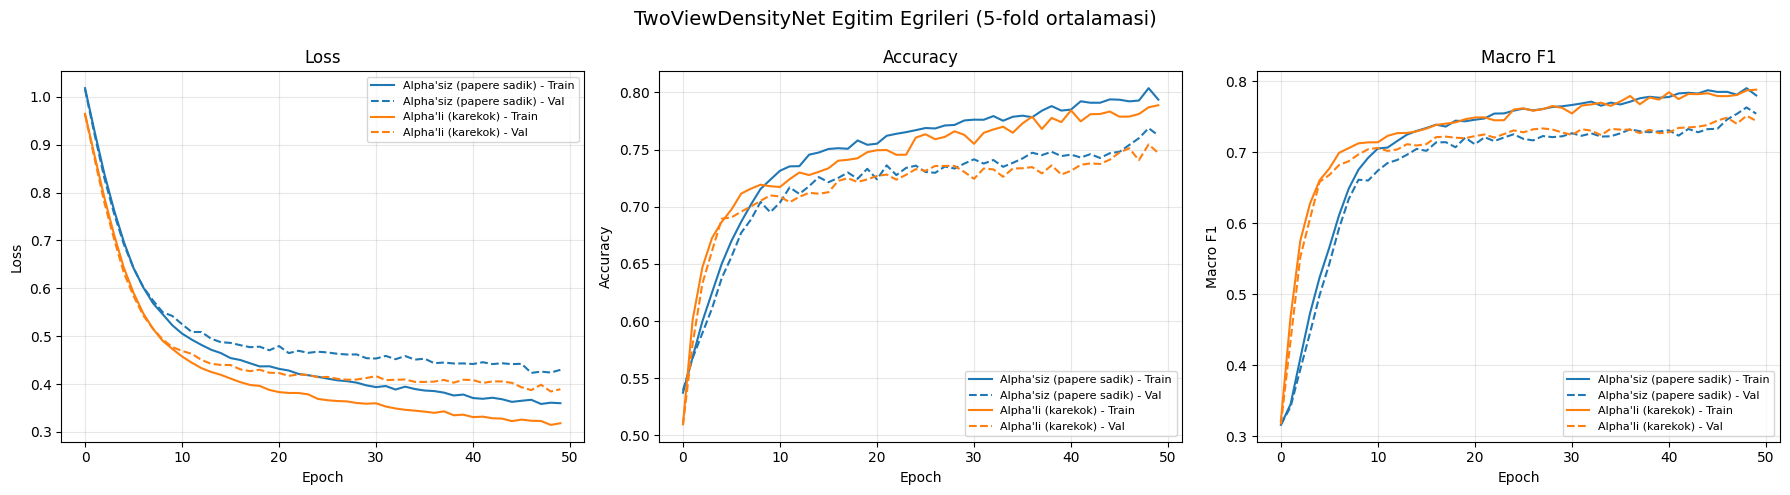

Kaydedildi: /content/drive/MyDrive/breast_density/TwoViewDensityNet_paper_faithful/comparison_training_curves.png


In [ ]:
import matplotlib.pyplot as plt

# Average training curves across folds for each experiment
# Her deney icin foldlar arasi ortalama egitim egrileri
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = [
    ("loss", "Loss"),
    ("accuracy", "Accuracy"),
    ("macro_f1", "Macro F1"),
]

colors = {"Alpha'siz (papere sadik)": "tab:blue", "Alpha'li (karekok)": "tab:orange"}

for ax_i, (metric, title) in enumerate(metrics_to_plot):
    ax = axes[ax_i]
    for name, log_df in logs.items():
        if log_df is None:
            continue
        # Mean across folds per epoch
        # Epoch basina foldlar arasi ortalama
        mean_by_epoch = log_df.groupby("epoch")[[f"train_{metric}", f"val_{metric}"]].mean()

        c = colors[name]
        ax.plot(mean_by_epoch.index, mean_by_epoch[f"train_{metric}"],
                color=c, linestyle="-", label=f"{name} - Train")
        ax.plot(mean_by_epoch.index, mean_by_epoch[f"val_{metric}"],
                color=c, linestyle="--", label=f"{name} - Val")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("TwoViewDensityNet Egitim Egrileri (5-fold ortalamasi)", fontsize=14)
plt.tight_layout()

save_path = os.path.join(ROOT_NOALPHA, "comparison_training_curves.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")

OZET KARSILASTIRMA (5-fold ortalama +/- std)
                   Deney          Accuracy          Macro F1         Macro AUC F1 (a) F1 (b) F1 (c) F1 (d)
Alpha'siz (papere sadik) 0.7385 +/- 0.0175 0.7242 +/- 0.0246 0.9256 +/- 0.0083 0.6275 0.7497 0.7411 0.7784
      Alpha'li (karekok) 0.7305 +/- 0.0225 0.7260 +/- 0.0254 0.9233 +/- 0.0087 0.6700 0.7299 0.7281 0.7762


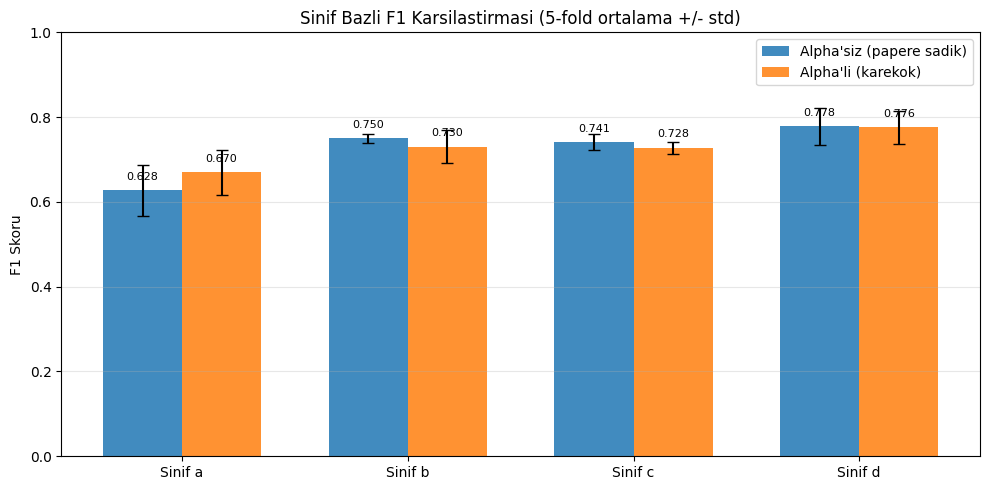


Kaydedildi: /content/drive/MyDrive/breast_density/TwoViewDensityNet_paper_faithful/comparison_per_class_f1.png


In [ ]:
# Summary table: mean +/- std for both experiments
# Ozet tablo: iki deney icin ortalama +/- std
print("=" * 70)
print("OZET KARSILASTIRMA (5-fold ortalama +/- std)")
print("=" * 70)

summary_rows = []
for name, prog in results.items():
    row = {"Deney": name}
    for col, label in [("test_accuracy", "Accuracy"),
                       ("test_macro_f1", "Macro F1"),
                       ("test_macro_auc", "Macro AUC")]:
        row[label] = f"{prog[col].mean():.4f} +/- {prog[col].std():.4f}"
    for c in CLASSES:
        row[f"F1 ({c})"] = f"{prog[f'test_f1_{c}'].mean():.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Per-class F1 bar chart
# Sinif basina F1 cubuk grafigi
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(CLASSES))
width = 0.35

for i, (name, prog) in enumerate(results.items()):
    means = [prog[f"test_f1_{c}"].mean() for c in CLASSES]
    stds = [prog[f"test_f1_{c}"].std() for c in CLASSES]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, means, width, yerr=stds, capsize=4,
                  label=name, color=colors[name], alpha=0.85)
    # Annotate values
    # Degerleri yaz
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, m + 0.02, f"{m:.3f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"Sinif {c}" for c in CLASSES])
ax.set_ylabel("F1 Skoru")
ax.set_title("Sinif Bazli F1 Karsilastirmasi (5-fold ortalama +/- std)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, 1.0)

plt.tight_layout()
save_path = os.path.join(ROOT_NOALPHA, "comparison_per_class_f1.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nKaydedildi: {save_path}")

Alpha'siz deney tahminleri hesaplaniyor...
Alpha'li deney tahminleri hesaplaniyor...
Tamamlandi.



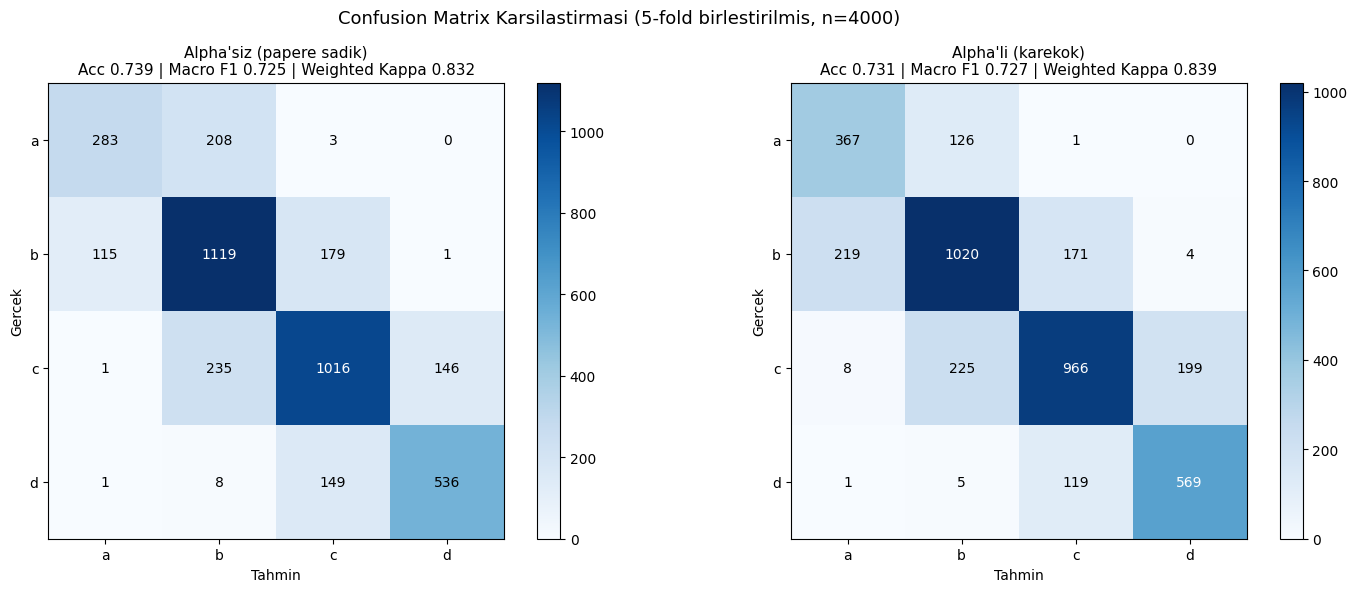

Kaydedildi: /content/drive/MyDrive/breast_density/TwoViewDensityNet_paper_faithful/comparison_confusion_matrices.png

=== Sinif kaymasi karsilastirmasi ===
Hata turu            Alpha siz    Alpha li     Degisim
-------------------------------------------------------
a -> b               208          126          -82 (azaldi)
d -> c               149          119          -30 (azaldi)
b -> c               179          171          -8 (azaldi)
c -> b               235          225          -10 (azaldi)
a -> d (kritik)      0            0            +0 (ayni)
d -> a (kritik)      1            1            +0 (ayni)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score, f1_score
from torch.utils.data import DataLoader

def collect_oof_predictions(root_path):
    # Collect out-of-fold predictions from all 5 folds of an experiment
    # Bir deneyin 5 fold'undan fold-disi tahminleri topla
    # Each sample is predicted by the model that did not train on it
    # Her ornek, onun uzerinde egitilmemis model tarafindan tahmin edilir
    all_labels, all_preds = [], []

    for fold in range(5):
        test_df_f = breast_df[breast_df["fold"] == fold].copy()
        test_loader = DataLoader(BreastDensityDataset(test_df_f, eval_transform),
                                 batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=2, pin_memory=True)

        best_path = os.path.join(root_path, f"fold_{fold}", "best.pt")
        model = TwoViewDensityNet(num_classes=4, pretrained=False).to(device)
        ck = torch.load(best_path, map_location=device)
        model.load_state_dict(ck["model_state"])

        criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=None)
        _, labels, preds, _ = evaluate(model, test_loader, criterion, device)

        all_labels.append(labels)
        all_preds.append(preds)

        del model
        torch.cuda.empty_cache()

    return np.concatenate(all_labels), np.concatenate(all_preds)

# Collect predictions for both experiments
# Iki deney icin tahminleri topla
print("Alpha'siz deney tahminleri hesaplaniyor...")
labels_noalpha, preds_noalpha = collect_oof_predictions(ROOT_NOALPHA)

print("Alpha'li deney tahminleri hesaplaniyor...")
labels_alpha, preds_alpha = collect_oof_predictions(ROOT_ALPHA)

print("Tamamlandi.\n")

# Plot side-by-side confusion matrices
# Yan yana confusion matrix ciz
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

experiments_cm = [
    ("Alpha'siz (papere sadik)", labels_noalpha, preds_noalpha),
    ("Alpha'li (karekok)", labels_alpha, preds_alpha),
]

for ax, (name, labels, preds) in zip(axes, experiments_cm):
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, cmap="Blues")

    acc = accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average="macro")
    wk = cohen_kappa_score(labels, preds, weights="quadratic")

    ax.set_title(f"{name}\nAcc {acc:.3f} | Macro F1 {mf1:.3f} | Weighted Kappa {wk:.3f}",
                 fontsize=11)
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gercek")
    ax.set_xticks(range(len(CLASSES)))
    ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES)
    ax.set_yticklabels(CLASSES)

    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)

    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Confusion Matrix Karsilastirmasi (5-fold birlestirilmis, n=4000)", fontsize=13)
plt.tight_layout()

save_path = os.path.join(ROOT_NOALPHA, "comparison_confusion_matrices.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: {save_path}")

# Print key error comparisons
# Anahtar hata karsilastirmalarini yazdir
print("\n=== Sinif kaymasi karsilastirmasi ===")
cm_no = confusion_matrix(labels_noalpha, preds_noalpha)
cm_al = confusion_matrix(labels_alpha, preds_alpha)

a_i, b_i, c_i, d_i = 0, 1, 2, 3
print(f"{'Hata turu':<20} {'Alpha siz':<12} {'Alpha li':<12} {'Degisim'}")
print("-" * 55)
for (src, dst, name) in [(a_i, b_i, "a -> b"), (d_i, c_i, "d -> c"),
                          (b_i, c_i, "b -> c"), (c_i, b_i, "c -> b"),
                          (a_i, d_i, "a -> d (kritik)"), (d_i, a_i, "d -> a (kritik)")]:
    v_no, v_al = cm_no[src, dst], cm_al[src, dst]
    change = v_al - v_no
    arrow = "azaldi" if change < 0 else ("artti" if change > 0 else "ayni")
    print(f"{name:<20} {v_no:<12} {v_al:<12} {change:+d} ({arrow})")